In [ ]:
from cnn_connectome.datasets.natural_movie import NaturalMovie, RenderedNaturalMov
from cnn_connectome.utils.plotting import use_static_flyvis_colorbar
from flyvis.analysis import animations
import numpy as np
from pathlib import Path
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from math import ceil
sns.set_context("poster")
plt.rcParams["figure.dpi"] = 100

/home/guardomayas/NUIN/cnn_connectome_v2/src/cnn_connectome/datasets/natural_movie.py:193: SyntaxWarning: invalid escape sequence '\q'
  {\bar{L}(p)}, \qquad \bar{L}(p) =
/home/guardomayas/miniforge3/envs/cnn_connectome/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = Path("/home/guardomayas/NUIN/pano_scenes/")
PPD = 360/(927) #Imgs width #Pano scenes (251, 927)
ommSizePix = int(np.ceil(5/PPD))  #Equivalent to kernel size in Conv2d
print("Pixel size (deg):", f"{PPD:.3f}")
print("Omm size (pixels):", ommSizePix, '\n')

print("Full eye image requirements:")
print(30*ommSizePix+1, "x", 30*ommSizePix+1, "Px" )


Pixel size (deg): 0.388
Omm size (pixels): 13 

Full eye image requirements:
391 x 391 Px


In [ ]:
n_scenes_total = 10        # or len(mat_files) in your natural_scenes folder
batch_size = 5
n_batches = ceil(n_scenes_total / batch_size)

render_cfgs = []
for bidx in range(n_batches):
    cfg = RenderedNaturalMov.Config(
        extent=9,
        kernel_size=ommSizePix,
        subset_idx=[],          # or restrict to some movies if you want
        data_path=data_path,
        batch_idx=bidx,
        batch_size=batch_size,
        traces_per_img=2,
        phases_per_img=3,
        halfLife=0.2,
        velStd=100,
        sampleFreq=60,
        totalTime=3,
        fov=250,
        percentile_scale=99.0
        
    )
    render_cfgs.append(cfg)

# One big dataset over ALL batches
dataset = NaturalMovie(render_cfgs, _init_cache=False)

print("Total sequences:", len(dataset))

[Vel] vel_traces: (5, 2, 181)
[Vel] positions:  (5, 2, 181)
[Phase] Phase indices: (3, 927)
[Movies] Total movies: 30
[Render] all_movies: (30, 181, 251, 250)


Rendering natural movies: 100%|██████████| 30/30 [00:22<00:00,  1.33it/s]


[Vel] vel_traces: (5, 2, 181)
[Vel] positions:  (5, 2, 181)
[Phase] Phase indices: (3, 927)
[Movies] Total movies: 30
[Render] all_movies: (30, 181, 251, 250)


Rendering natural movies: 100%|██████████| 30/30 [00:16<00:00,  1.84it/s]

Total sequences: 60


In [ ]:
batch = dataset[0]
lum = batch['lum']
sp_contrast = batch['spatial_contrast']
t_contrast = batch['temporal_contrast']
vel = batch['vel']
print(lum.shape, sp_contrast.shape, t_contrast.shape)#T,1,Hexals
print("Velocity", vel.shape, vel.max(), vel.min())
print("Raw luminance", lum.max(), lum.min())
print("Spatial contrast", sp_contrast.max(), sp_contrast.min())
print("Temporal contrast", t_contrast.max(), t_contrast.min())

torch.Size([181, 1, 271]) torch.Size([181, 1, 271]) torch.Size([181, 1, 271])
Velocity torch.Size([181]) tensor(260.5655) tensor(-175.3370)
Raw luminance tensor(0.7902) tensor(0.0191)
Spatial contrast tensor(7.5791) tensor(-0.7572)
Temporal contrast tensor(3.0861) tensor(-0.9125)


In [11]:
show = sp_contrast
print(show[0].squeeze().min(), show[0].squeeze().max())
if show is lum:
    vmin = 0.0
    vmax = 1.0
else:
    vmin = -1.0
    vmax =  2.2

tensor(-0.6289) tensor(4.0592)


/tmp/ipykernel_13989/4255779779.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


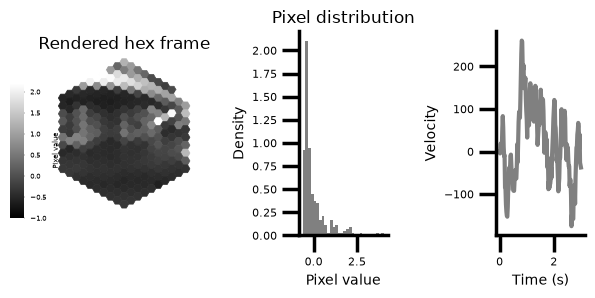

In [ ]:
from flyvis.analysis.visualization import plt_utils, plots
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(6,3.5),
    gridspec_kw={'width_ratios': [1.5, 1, 1]}  # make hex scatter wider
)

fig, ax1, _ = plots.quick_hex_scatter(
     show[0], fig=fig, ax=ax1, cbar_x_offset=-40,vmin=vmin, vmax=vmax, cmap='gray')
ax1.set_title("Rendered hex frame", fontsize=12)
# Distribution
ax2.hist(show[0].squeeze(), bins=30, color='gray', density=True)
ax2.set_xlabel("Pixel value", fontsize=10)
ax2.set_ylabel("Density", fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_title("Pixel distribution", fontsize=12)

ax3.plot(np.arange(len(vel))*dataset.dt, vel, color='gray')
ax3.set_xlabel("Time (s)", fontsize=10)
ax3.set_ylabel("Velocity", fontsize=10)
ax3.tick_params(axis='both', which='major', labelsize=8)
plt.tight_layout()
plt.show()


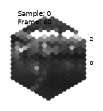

In [15]:
animation = animations.HexScatter(show[None,::3], 
                                  vmin=vmin,
                                  vmax=vmax)

use_static_flyvis_colorbar(animation)
animation.animate_in_notebook()